# Week 2 — Mini-DINO from First Principles

This notebook implements a compact DINO-style self-supervised learning pipeline on CIFAR-10.

**Pipeline:** multi-crop augmentation → student and teacher TinyViT models → DINO cross-view loss → teacher EMA update → embeddings and visualizations.

- The model trains without using CIFAR-10 labels. Labels are used only to color the PCA and t-SNE plots.
- Two global crops and two local crops are generated for each image.
- The teacher receives only the two global crops.
- The attention visualization is collected from the same attention layers that are trained with the model.
- This is a small educational implementation, not a reproduction of every detail in the original DINO paper.

## Environment and imports

Run the notebook from top to bottom. In Colab, select a GPU runtime for faster training.

In [1]:
import json
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
Device: cuda
GPU: Tesla T4


## Load CIFAR-10 and select a reproducible subset

The dataset is loaded without a transform so that augmentations can operate on the original PIL images. Only 5,000 training images are used for this mini-project.

In [2]:
DATA_DIR = "./data"
NUM_IMAGES = 5000

cifar10 = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=None
)

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(cifar10), generator=generator)[:NUM_IMAGES].tolist()
selected_dataset = Subset(cifar10, indices)

print("Full CIFAR-10 training split:", len(cifar10))
print("Selected training images:", len(selected_dataset))
print("Example label (not used for training):", selected_dataset[0][1])

100%|██████████| 170M/170M [30:08<00:00, 94.3kB/s]


Full CIFAR-10 training split: 50000
Selected training images: 5000
Example label (not used for training): 6


## Define multi-crop augmentation

Each image produces two global crops of size 32×32 and two local crops of size 16×16. Normalization is applied after converting each crop to a tensor.

In [3]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

normalize = transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD)

global_transform = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1
        )
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    normalize
])

local_transform = transforms.Compose([
    transforms.RandomResizedCrop(16, scale=(0.3, 0.8)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1
        )
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    normalize
])

class MultiCropTransform:
    def __call__(self, image):
        # Two global views give the teacher broad context.
        global_views = [global_transform(image), global_transform(image)]
        # Two local views encourage matching representations across scales.
        local_views = [local_transform(image), local_transform(image)]
        return global_views + local_views

multi_crop_transform = MultiCropTransform()

print("Multi-crop transform defined.")

Multi-crop transform defined.


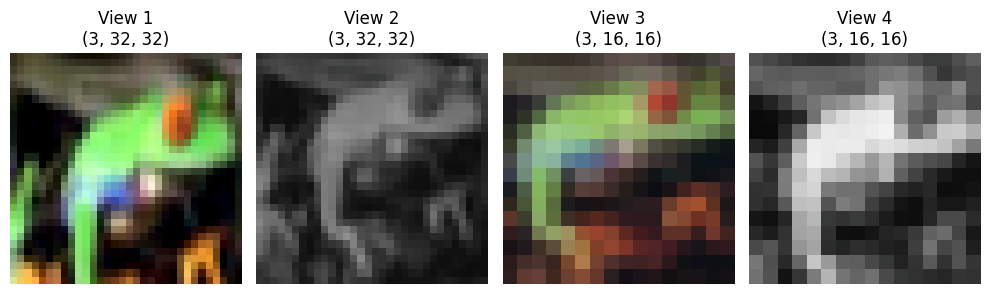

The sample label is 6 (not used in DINO training).


In [4]:
# Visualize the four views generated from one training image.
sample_image, sample_label = cifar10[indices[0]]
views = multi_crop_transform(sample_image)

mean_tensor = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
std_tensor = torch.tensor(CIFAR_STD).view(3, 1, 1)

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for index, (axis, view) in enumerate(zip(axes, views)):
    display_view = (view * std_tensor + mean_tensor).clamp(0, 1)
    axis.imshow(display_view.permute(1, 2, 0).numpy())
    axis.set_title(f"View {index + 1}\n{tuple(view.shape)}")
    axis.axis("off")
plt.tight_layout()
plt.show()
print("The sample label is", sample_label, "(not used in DINO training).")

## Create the DINO dataset and data loader

The training dataset returns only the four augmented views. It deliberately does not return labels to the training loop.

In [5]:
class DINODataset(Dataset):
    def __init__(self, base_dataset, selected_indices, transform):
        self.base_dataset = base_dataset
        self.selected_indices = selected_indices
        self.transform = transform

    def __len__(self):
        return len(self.selected_indices)

    def __getitem__(self, item):
        image, _label = self.base_dataset[self.selected_indices[item]]
        return self.transform(image)

BATCH_SIZE = 64
NUM_WORKERS = 2

dino_dataset = DINODataset(cifar10, indices, multi_crop_transform)
dino_loader = DataLoader(
    dino_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True
)

crop_batch = next(iter(dino_loader))
print("Number of crop groups:", len(crop_batch))
for crop_index, crop_group in enumerate(crop_batch):
    print(f"Crop group {crop_index + 1}: {tuple(crop_group.shape)}")

Number of crop groups: 4
Crop group 1: (64, 3, 32, 32)
Crop group 2: (64, 3, 32, 32)
Crop group 3: (64, 3, 16, 16)
Crop group 4: (64, 3, 16, 16)


## Configure the TinyViT model

CIFAR-10 images are 32×32. With patch size 8, a global view contains 16 patches plus one CLS token. Local 16×16 crops contain 4 patches plus one CLS token.

In [6]:
IMAGE_CHANNELS = 3
PATCH_SIZE = 8
EMBED_DIM = 192
NUM_HEADS = 3
NUM_LAYERS = 4
MLP_DIM = 384
OUT_DIM = 2048

GLOBAL_SIZE = 32
LOCAL_SIZE = 16

print("Global patches:", (GLOBAL_SIZE // PATCH_SIZE) ** 2)
print("Local patches:", (LOCAL_SIZE // PATCH_SIZE) ** 2)

Global patches: 16
Local patches: 4


## Build patch embedding and Transformer blocks

The custom attention block exposes attention weights from its final layer. Because these are the same layers used during training, the later attention visualization will not rely on randomly initialized replacement layers.

In [7]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_channels=IMAGE_CHANNELS, embed_dim=EMBED_DIM, patch_size=PATCH_SIZE):
        super().__init__()
        self.projection = nn.Conv2d(
            image_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

    def forward(self, images):
        # [B, C, H, W] -> [B, D, H/P, W/P] -> [B, N, D]
        patches = self.projection(images)
        return patches.flatten(2).transpose(1, 2)


class AttentionEncoderLayer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_dim=MLP_DIM):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim)
        )

    def forward(self, tokens, return_attention=False):
        normalized = self.norm1(tokens)
        attended, attention = self.attention(
            normalized,
            normalized,
            normalized,
            need_weights=return_attention,
            average_attn_weights=False
        )
        tokens = tokens + attended
        tokens = tokens + self.mlp(self.norm2(tokens))
        if return_attention:
            return tokens, attention
        return tokens


class DINOProjectionHead(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, out_dim=OUT_DIM):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, out_dim)
        )

    def forward(self, embeddings):
        return self.layers(embeddings)


class TinyViT(nn.Module):
    def __init__(
        self,
        image_size=GLOBAL_SIZE,
        patch_size=PATCH_SIZE,
        embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS,
        num_layers=NUM_LAYERS,
        mlp_dim=MLP_DIM,
        out_dim=OUT_DIM
    ):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.patch_embed = PatchEmbedding(
            image_channels=IMAGE_CHANNELS,
            embed_dim=embed_dim,
            patch_size=patch_size
        )

        base_grid = image_size // patch_size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, base_grid * base_grid + 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.transformer = nn.ModuleList([
            AttentionEncoderLayer(embed_dim, num_heads, mlp_dim)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.projection_head = DINOProjectionHead(embed_dim, out_dim)

    def get_position_embeddings(self, height, width):
        grid_height = height // self.patch_size
        grid_width = width // self.patch_size
        base_grid = int((self.pos_embed.shape[1] - 1) ** 0.5)

        cls_position = self.pos_embed[:, :1, :]
        patch_positions = self.pos_embed[:, 1:, :]
        patch_positions = patch_positions.reshape(
            1, base_grid, base_grid, self.embed_dim
        ).permute(0, 3, 1, 2)

        if (grid_height, grid_width) != (base_grid, base_grid):
            patch_positions = F.interpolate(
                patch_positions,
                size=(grid_height, grid_width),
                mode="bicubic",
                align_corners=False
            )

        patch_positions = patch_positions.flatten(2).transpose(1, 2)
        return torch.cat([cls_position, patch_positions], dim=1)

    def forward(self, images, return_embedding=False, return_attention=False):
        batch_size, _channels, height, width = images.shape
        patch_tokens = self.patch_embed(images)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls_tokens, patch_tokens], dim=1)
        tokens = tokens + self.get_position_embeddings(height, width)

        last_attention = None
        for layer_index, layer in enumerate(self.transformer):
            is_last_layer = layer_index == len(self.transformer) - 1
            if return_attention and is_last_layer:
                tokens, last_attention = layer(tokens, return_attention=True)
            else:
                tokens = layer(tokens)

        cls_embedding = self.norm(tokens[:, 0, :])
        if return_attention:
            return cls_embedding, last_attention
        if return_embedding:
            return cls_embedding
        return self.projection_head(cls_embedding)

# Quick shape test for global and local crops.
test_model = TinyViT().to(device)
with torch.no_grad():
    global_output = test_model(torch.randn(2, 3, 32, 32, device=device))
    local_output = test_model(torch.randn(2, 3, 16, 16, device=device))
    cls_output = test_model(
        torch.randn(2, 3, 32, 32, device=device),
        return_embedding=True
    )
print("Global projection output:", tuple(global_output.shape))
print("Local projection output:", tuple(local_output.shape))
print("CLS embedding output:", tuple(cls_output.shape))
del test_model

Global projection output: (2, 2048)
Local projection output: (2, 2048)
CLS embedding output: (2, 192)


## Create student and teacher networks

The student is optimized using gradients. The teacher starts with identical weights, has gradients disabled, and is updated using an exponential moving average (EMA) of student parameters.

In [8]:
student = TinyViT().to(device)
teacher = TinyViT().to(device)
teacher.load_state_dict(student.state_dict())

for parameter in teacher.parameters():
    parameter.requires_grad = False
teacher.eval()

print("Student and teacher start with matching weights:",
      all(torch.equal(s, t) for s, t in zip(student.parameters(), teacher.parameters())))

Student and teacher start with matching weights: True


## Define the DINO loss and EMA update

Teacher probabilities are sharpened using a lower temperature and centered using a running average of teacher outputs. The student is trained to match teacher targets from different views; matching a global view to its own corresponding teacher view is excluded.

In [9]:
STUDENT_TEMP = 0.1
TEACHER_TEMP = 0.04
MOMENTUM = 0.996
CENTER_MOMENTUM = 0.9


class DINOLoss(nn.Module):
    def __init__(
        self,
        out_dim=OUT_DIM,
        student_temp=STUDENT_TEMP,
        teacher_temp=TEACHER_TEMP,
        center_momentum=CENTER_MOMENTUM
    ):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_outputs, teacher_outputs):
        student_log_probs = [
            F.log_softmax(output / self.student_temp, dim=-1)
            for output in student_outputs
        ]
        teacher_probs = [
            F.softmax((output - self.center) / self.teacher_temp, dim=-1).detach()
            for output in teacher_outputs
        ]

        total_loss = 0.0
        number_of_terms = 0
        for teacher_index, teacher_prob in enumerate(teacher_probs):
            for student_index, student_log_prob in enumerate(student_log_probs):
                # Skip matching global views (teacher view 0/student view 0 and view 1/view 1).
                if student_index == teacher_index:
                    continue
                cross_entropy = -torch.sum(
                    teacher_prob * student_log_prob, dim=-1
                ).mean()
                total_loss = total_loss + cross_entropy
                number_of_terms += 1

        return total_loss / number_of_terms

    @torch.no_grad()
    def update_center(self, teacher_outputs):
        all_teacher_outputs = torch.cat(teacher_outputs, dim=0)
        batch_center = all_teacher_outputs.mean(dim=0, keepdim=True)
        self.center.mul_(self.center_momentum).add_(
            batch_center, alpha=1 - self.center_momentum
        )


@torch.no_grad()
def update_teacher_ema(student_model, teacher_model, momentum=MOMENTUM):
    for student_parameter, teacher_parameter in zip(
        student_model.parameters(), teacher_model.parameters()
    ):
        teacher_parameter.mul_(momentum).add_(
            student_parameter, alpha=1 - momentum
        )

## Train Mini-DINO

The student processes all four crop groups. The teacher processes only the two global crop groups. Each training batch updates the student by backpropagation, updates the teacher by EMA, and updates the teacher-output center.

In [10]:
EPOCHS = 10
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.04

optimizer = torch.optim.AdamW(
    student.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
dino_loss = DINOLoss().to(device)
training_losses = []

start_time = time.time()
for epoch in range(EPOCHS):
    student.train()
    teacher.eval()
    running_loss = 0.0

    for crop_groups in dino_loader:
        crop_groups = [
            crop_group.to(device, non_blocking=True)
            for crop_group in crop_groups
        ]

        student_outputs = [student(crop_group) for crop_group in crop_groups]

        with torch.no_grad():
            teacher_outputs = [
                teacher(crop_groups[0]),
                teacher(crop_groups[1])
            ]

        loss = dino_loss(student_outputs, teacher_outputs)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        update_teacher_ema(student, teacher, momentum=MOMENTUM)
        dino_loss.update_center(teacher_outputs)
        running_loss += loss.item()

    epoch_loss = running_loss / len(dino_loader)
    training_losses.append(epoch_loss)
    elapsed = (time.time() - start_time) / 60
    print(f"Epoch {epoch + 1:02d}/{EPOCHS} | loss={epoch_loss:.4f} | elapsed={elapsed:.1f} min")

student.eval()
teacher.eval()

Epoch 01/10 | loss=7.3527 | elapsed=0.3 min
Epoch 02/10 | loss=7.2938 | elapsed=0.6 min
Epoch 03/10 | loss=7.2138 | elapsed=0.9 min
Epoch 04/10 | loss=7.1000 | elapsed=1.2 min
Epoch 05/10 | loss=6.9910 | elapsed=1.5 min
Epoch 06/10 | loss=6.8654 | elapsed=1.8 min
Epoch 07/10 | loss=6.7608 | elapsed=2.1 min
Epoch 08/10 | loss=6.6469 | elapsed=2.4 min
Epoch 09/10 | loss=6.5253 | elapsed=2.7 min
Epoch 10/10 | loss=6.4282 | elapsed=3.0 min


TinyViT(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(3, 192, kernel_size=(8, 8), stride=(8, 8))
  )
  (transformer): ModuleList(
    (0-3): 4 x AttentionEncoderLayer(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=192, out_features=384, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=384, out_features=192, bias=True)
      )
    )
  )
  (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (projection_head): DINOProjectionHead(
    (layers): Sequential(
      (0): Linear(in_features=192, out_features=192, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=192, out_features=192, bias=True)
      (3): GELU(approximate=

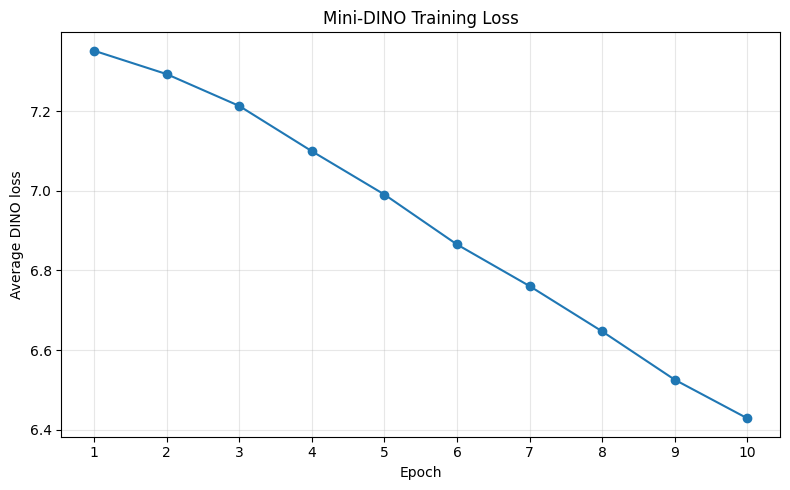

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(training_losses) + 1), training_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average DINO loss")
plt.title("Mini-DINO Training Loss")
plt.xticks(range(1, len(training_losses) + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Extract teacher embeddings for evaluation

This uses the CIFAR-10 test split and a deterministic transform. The labels are retained only to color visualizations; they do not enter the training loss.

In [12]:
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize
])

eval_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=eval_transform
)

NUM_EVAL_IMAGES = 1000
eval_subset = Subset(eval_dataset, list(range(NUM_EVAL_IMAGES)))
eval_loader = DataLoader(
    eval_subset,
    batch_size=64,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

all_embeddings = []
all_labels = []
teacher.eval()

with torch.no_grad():
    for images, labels in eval_loader:
        images = images.to(device, non_blocking=True)
        embeddings = teacher(images, return_embedding=True)
        all_embeddings.append(embeddings.cpu())
        all_labels.append(labels.cpu())

all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

print("Embedding matrix:", all_embeddings.shape)
print("Labels for visualization:", all_labels.shape)

Embedding matrix: (1000, 192)
Labels for visualization: (1000,)


## PCA visualization

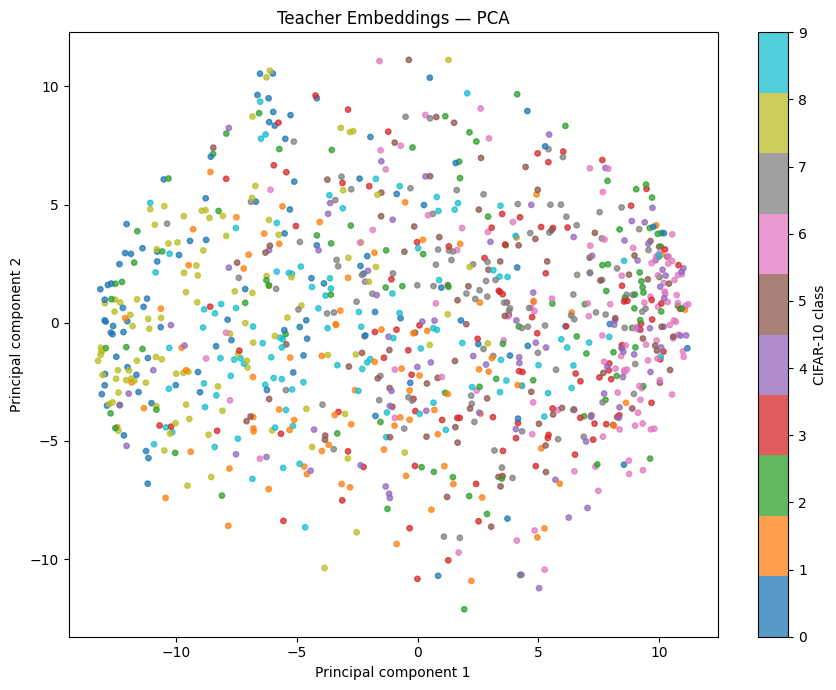

Explained variance ratio: [0.52203524 0.18768968]
Total variance retained: 0.7097249


In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
pca_embeddings = pca.fit_transform(all_embeddings)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    pca_embeddings[:, 0], pca_embeddings[:, 1],
    c=all_labels, cmap="tab10", s=15, alpha=0.75
)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Teacher Embeddings — PCA")
plt.colorbar(scatter, label="CIFAR-10 class")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", pca.explained_variance_ratio_.sum())

## t-SNE visualization

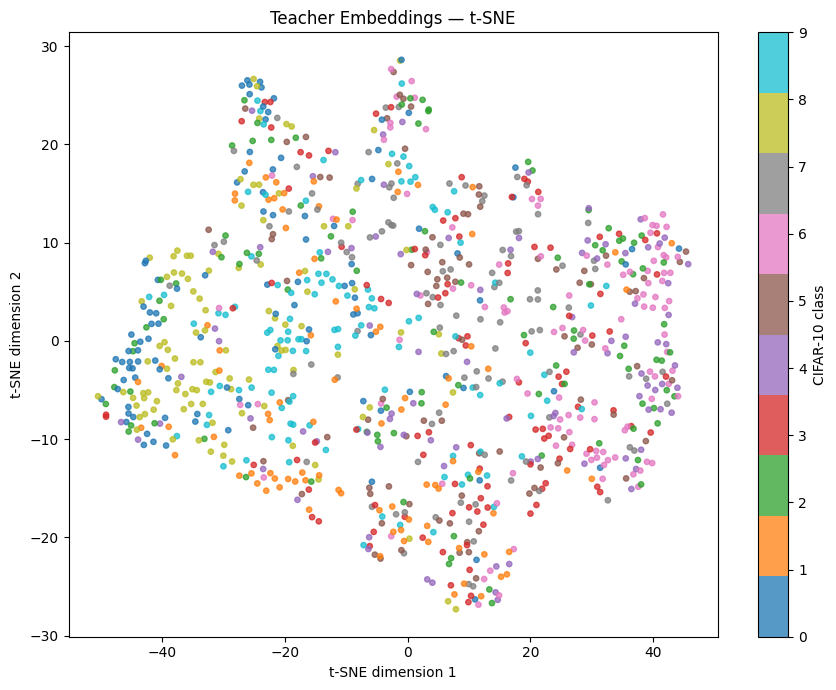

In [14]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=SEED
)
tsne_embeddings = tsne.fit_transform(all_embeddings)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    tsne_embeddings[:, 0], tsne_embeddings[:, 1],
    c=all_labels, cmap="tab10", s=15, alpha=0.75
)
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.title("Teacher Embeddings — t-SNE")
plt.colorbar(scatter, label="CIFAR-10 class")
plt.tight_layout()
plt.show()

## Visualize CLS attention from the trained teacher

Attention weights are taken directly from the teacher's trained final Transformer layer. The 16 patch scores are reshaped to a 4×4 map and upsampled for display. Attention is a qualitative visualization, not a class explanation or a quantitative performance metric.

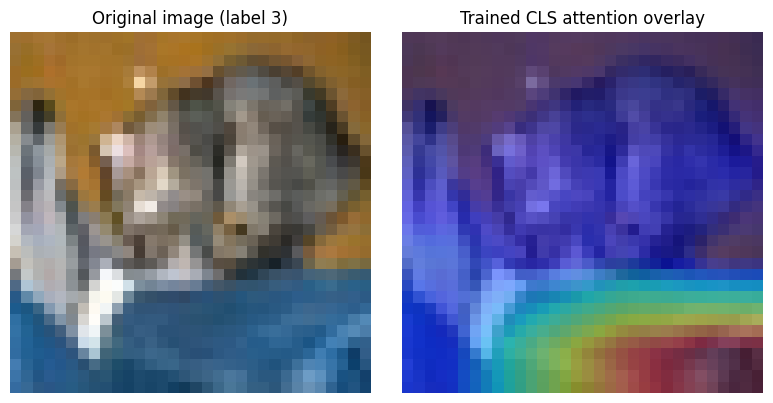

Attention tensor shape: (1, 3, 17, 17)


In [15]:
image_tensor, image_label = eval_dataset[0]
image_batch = image_tensor.unsqueeze(0).to(device)

teacher.eval()
with torch.no_grad():
    cls_embedding, attention = teacher(
        image_batch,
        return_attention=True
    )

# attention shape: [batch, heads, tokens, tokens]
mean_attention = attention[0].mean(dim=0)
cls_attention = mean_attention[0, 1:]
grid_size = image_batch.shape[-1] // PATCH_SIZE
attention_map = cls_attention.reshape(grid_size, grid_size)

attention_resized = F.interpolate(
    attention_map.unsqueeze(0).unsqueeze(0),
    size=(32, 32),
    mode="bilinear",
    align_corners=False
)[0, 0].cpu().numpy()

display_image = (
    image_tensor * torch.tensor(CIFAR_STD).view(3, 1, 1)
    + torch.tensor(CIFAR_MEAN).view(3, 1, 1)
).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(display_image)
axes[0].set_title(f"Original image (label {image_label})")
axes[0].axis("off")
axes[1].imshow(display_image)
axes[1].imshow(attention_resized, cmap="jet", alpha=0.5)
axes[1].set_title("Trained CLS attention overlay")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print("Attention tensor shape:", tuple(attention.shape))

## EMA ablation experiment

This compares EMA-updated teacher training with a fixed-teacher baseline. To limit runtime, the ablation uses a smaller subset and fewer epochs than the main training run. Interpret loss curves cautiously: a fixed random teacher is a limited baseline, and loss alone does not establish embedding quality.

In [16]:
RUN_ABLATION = True
ABLATION_IMAGES = 1000
ABLATION_EPOCHS = 3

ablation_indices = indices[:ABLATION_IMAGES]
ablation_dataset = DINODataset(cifar10, ablation_indices, multi_crop_transform)
ablation_loader = DataLoader(
    ablation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True
)


def train_dino_ablation(use_ema, epochs=ABLATION_EPOCHS):
    student_model = TinyViT().to(device)
    teacher_model = TinyViT().to(device)
    teacher_model.load_state_dict(student_model.state_dict())
    for parameter in teacher_model.parameters():
        parameter.requires_grad = False
    teacher_model.eval()

    optimizer_ablation = torch.optim.AdamW(
        student_model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    loss_function = DINOLoss().to(device)
    epoch_losses = []

    for epoch in range(epochs):
        student_model.train()
        total_loss = 0.0

        for crop_groups in ablation_loader:
            crop_groups = [
                crop_group.to(device, non_blocking=True)
                for crop_group in crop_groups
            ]
            student_outputs = [student_model(group) for group in crop_groups]
            with torch.no_grad():
                teacher_outputs = [
                    teacher_model(crop_groups[0]),
                    teacher_model(crop_groups[1])
                ]

            loss = loss_function(student_outputs, teacher_outputs)
            optimizer_ablation.zero_grad(set_to_none=True)
            loss.backward()
            optimizer_ablation.step()

            if use_ema:
                update_teacher_ema(student_model, teacher_model, momentum=MOMENTUM)
            loss_function.update_center(teacher_outputs)
            total_loss += loss.item()

        epoch_losses.append(total_loss / len(ablation_loader))
        print(
            f"{'EMA' if use_ema else 'No EMA'} "
            f"epoch {epoch + 1}/{epochs}: {epoch_losses[-1]:.4f}"
        )

    return student_model, teacher_model, epoch_losses


if RUN_ABLATION:
    student_ema, teacher_ema, losses_ema = train_dino_ablation(use_ema=True)
    student_no_ema, teacher_no_ema, losses_no_ema = train_dino_ablation(use_ema=False)

EMA epoch 1/3: 7.2814
EMA epoch 2/3: 7.4639
EMA epoch 3/3: 7.4002
No EMA epoch 1/3: 7.3161
No EMA epoch 2/3: 7.4890
No EMA epoch 3/3: 7.4526


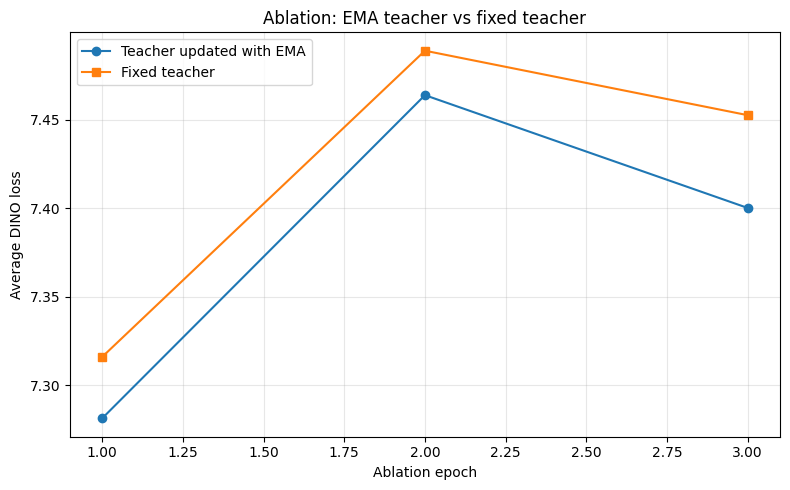

In [17]:
if RUN_ABLATION:
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses_ema) + 1), losses_ema, marker="o", label="Teacher updated with EMA")
    plt.plot(range(1, len(losses_no_ema) + 1), losses_no_ema, marker="s", label="Fixed teacher")
    plt.xlabel("Ablation epoch")
    plt.ylabel("Average DINO loss")
    plt.title("Ablation: EMA teacher vs fixed teacher")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Save results, figures, and model checkpoints

The output folder is created under `Week-2/`. In Colab, download or copy this folder to Google Drive before the runtime ends if you want to keep it.

In [18]:
RESULTS_DIR = Path("Week-2/results")
CHECKPOINT_DIR = Path("Week-2/checkpoints")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Save training loss plot.
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(training_losses) + 1), training_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average DINO loss")
plt.title("Mini-DINO Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_loss.png", dpi=200, bbox_inches="tight")
plt.close()

# Save PCA plot.
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_embeddings[:, 0], pca_embeddings[:, 1],
                      c=all_labels, cmap="tab10", s=15, alpha=0.75)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Teacher Embeddings — PCA")
plt.colorbar(scatter, label="CIFAR-10 class")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca.png", dpi=200, bbox_inches="tight")
plt.close()

# Save t-SNE plot.
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1],
                      c=all_labels, cmap="tab10", s=15, alpha=0.75)
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.title("Teacher Embeddings — t-SNE")
plt.colorbar(scatter, label="CIFAR-10 class")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "tsne.png", dpi=200, bbox_inches="tight")
plt.close()

# Save attention overlay.
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(display_image)
axes[0].set_title("Original image")
axes[0].axis("off")
axes[1].imshow(display_image)
axes[1].imshow(attention_resized, cmap="jet", alpha=0.5)
axes[1].set_title("Trained CLS attention")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "attention_map.png", dpi=200, bbox_inches="tight")
plt.close()

# Save the ablation figure when the experiment was run.
if RUN_ABLATION:
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses_ema) + 1), losses_ema, marker="o", label="With EMA")
    plt.plot(range(1, len(losses_no_ema) + 1), losses_no_ema, marker="s", label="Fixed teacher")
    plt.xlabel("Epoch")
    plt.ylabel("Average DINO loss")
    plt.title("Ablation: EMA vs fixed teacher")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "ablation.png", dpi=200, bbox_inches="tight")
    plt.close()

# Save model weights.
torch.save(student.state_dict(), CHECKPOINT_DIR / "dino_student.pth")
torch.save(teacher.state_dict(), CHECKPOINT_DIR / "dino_teacher.pth")

training_config = {
    "dataset": "CIFAR-10",
    "training_images": NUM_IMAGES,
    "evaluation_images": NUM_EVAL_IMAGES,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "image_channels": IMAGE_CHANNELS,
    "patch_size": PATCH_SIZE,
    "embedding_dimension": EMBED_DIM,
    "projection_output_dimension": OUT_DIM,
    "transformer_layers": NUM_LAYERS,
    "attention_heads": NUM_HEADS,
    "student_temperature": STUDENT_TEMP,
    "teacher_temperature": TEACHER_TEMP,
    "teacher_momentum": MOMENTUM,
    "final_training_loss": float(training_losses[-1]),
    "device": str(device)
}
with open(CHECKPOINT_DIR / "training_config.json", "w") as file:
    json.dump(training_config, file, indent=2)

print("Saved results:")
for path in sorted(RESULTS_DIR.iterdir()):
    print(f"  {path} ({path.stat().st_size / 1024:.1f} KB)")
print("Saved checkpoints:")
for path in sorted(CHECKPOINT_DIR.iterdir()):
    print(f"  {path} ({path.stat().st_size / (1024 ** 2):.2f} MB)")

Saved results:
  Week-2/results/ablation.png (85.4 KB)
  Week-2/results/attention_map.png (28.4 KB)
  Week-2/results/pca.png (454.9 KB)
  Week-2/results/training_loss.png (64.9 KB)
  Week-2/results/tsne.png (466.2 KB)
Saved checkpoints:
  Week-2/checkpoints/dino_student.pth (6.50 MB)
  Week-2/checkpoints/dino_teacher.pth (6.50 MB)
  Week-2/checkpoints/training_config.json (0.00 MB)


## Reload the saved teacher checkpoint

This verifies that the teacher weights can be loaded into the same architecture.

In [19]:
reloaded_teacher = TinyViT().to(device)
state_dict = torch.load(
    CHECKPOINT_DIR / "dino_teacher.pth",
    map_location=device,
    weights_only=True
)
reloaded_teacher.load_state_dict(state_dict)
reloaded_teacher.eval()

with torch.no_grad():
    test_image = torch.randn(1, 3, 32, 32, device=device)
    test_embedding = reloaded_teacher(test_image, return_embedding=True)
print("Checkpoint reload successful.")
print("Test embedding shape:", tuple(test_embedding.shape))

Checkpoint reload successful.
Test embedding shape: (1, 192)


## Interpretation and limitations

- A falling DINO loss suggests the student is increasingly matching the teacher's cross-view targets, but it does not by itself prove semantic quality.
- PCA and t-SNE are exploratory visualizations of teacher CLS embeddings; cluster separation may be imperfect after only 10 epochs.
- The EMA ablation uses a fixed random teacher as the no-EMA baseline, so it is a simple educational comparison rather than a definitive scientific ablation.
- This compact implementation uses CIFAR-10, a small ViT, and a short training schedule. Results should not be directly compared with full-scale DINO paper results.